In [4]:
import pathlib
from argparse import ArgumentParser
import yaml
import torch
# import src.spatial_attn_lightning as attn_tracking_lightning
from src.spatial_attn_lightning import BinauralAttentionModule 


%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [3]:
### Get most recent config
config_path = "config/binaural_attn/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout.yaml"
ckpt_path = "attn_cue_models/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout/checkpoints/epoch=4-step=59392.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)


In [8]:
ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))


In [12]:
# for each ke in ckpt['state_dict'] remove ._orig_module from the key
new_state_dict = {}
for k, v in ckpt['state_dict'].items():
    if '_orig_mod.' in k:
        k = k.replace('_orig_mod.', '')
    new_state_dict[k] = v

ckpt['state_dict'] = new_state_dict

In [15]:
model = BinauralAttentionModule(config=config)


model.load_state_dict(ckpt['state_dict'])

Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
coch_affine: True
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


<All keys matched successfully>

In [16]:
attn_modules = model.attn_modules

In [17]:
attn_modules[0].bias.item()

1.373200211673975e-05

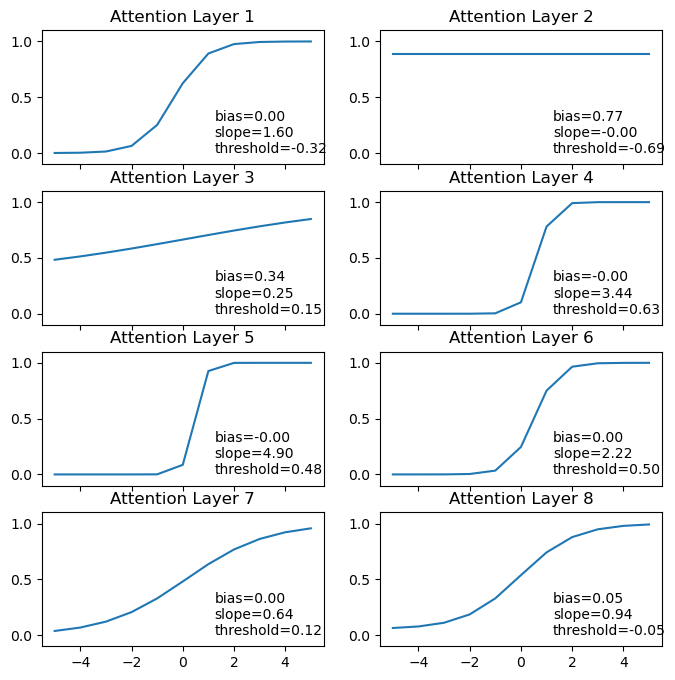

In [19]:

n_attn_blocks = len(attn_modules)   

fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True, figsize=(8,8))
axs = axs.ravel()
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-5,6)

for i, module in enumerate(attn_modules):
    bias = module.bias.item()
    slope = module.slope.item()
    threshold = module.threshold.item() 
    layer_name = f"Attention Layer {i+1}"

    axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
    axs[i].text(1.25, 0., f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    axs[i].set_title(layer_name)
    # axs[i].set_ylim(-0.1,1.1)
    axs[i].set_ylim(-0.1,1.1)

    
    
# plt.tight_layout()

## For compat with old binaural models

In [10]:
attn_params = {}
for param in model.named_parameters():
    if 'attn' in param[0]:
        print(param[0])
        layer, parameter = param[0].split('.')[3:]
        if layer not in attn_params:
            attn_params[layer] = {}
        attn_params[layer][parameter] = param[1].item()


('model.model_dict.attn0.bias', Parameter containing:
tensor([0.], requires_grad=True))


ValueError: not enough values to unpack (expected 2, got 1)

In [7]:
n_attn_blocks = len(attn_params)

## Plot attentional filters

In [10]:
n_attn_blocks

8

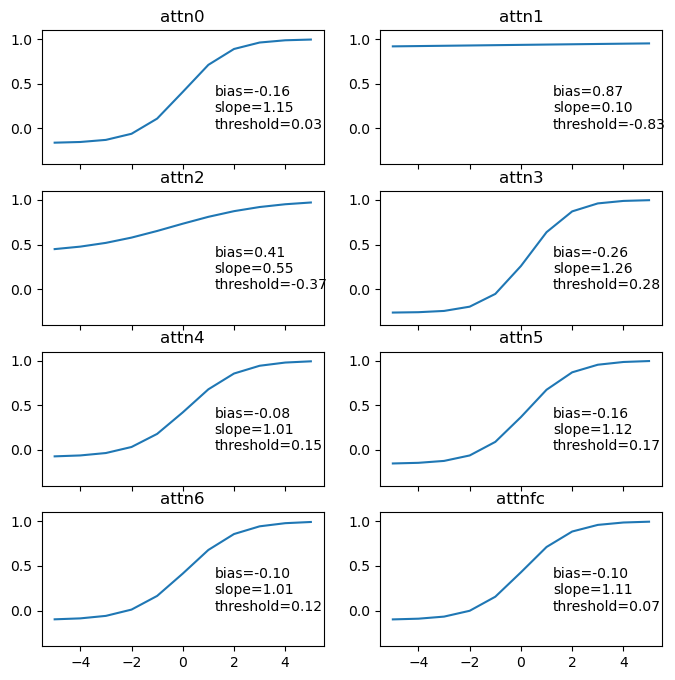

In [12]:
fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True, figsize=(8,8))
axs = axs.ravel()
layer_names = list(attn_params.keys())
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-5,6)

for i, layer in enumerate(attn_params.keys()):
    bias = attn_params[layer]['bias']
    slope = attn_params[layer]['slope']
    threshold = attn_params[layer]['threshold']

    axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
    axs[i].text(1.25, 0., f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    axs[i].set_title(layer_names[i])
    # axs[i].set_ylim(-0.1,1.1)
    axs[i].set_ylim(-0.4,1.1)

    
    
# plt.tight_layout()

# Look at cue-free arch with auxilary input

In [13]:
### Get most recent config
config_path = "config/binaural_attn/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue.yaml"
ckpt_path = "attn_cue_models/word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_no_constraints/checkpoints/epoch=1-step=12277-v7.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)


In [14]:
model = attn_tracking_lightning.BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=True)
model = model.eval()
attn_params = {}
for param in model.named_parameters():
    if 'attn' in param[0]:
        layer, parameter = param[0].split('.')[3:]
        if layer not in attn_params:
            attn_params[layer] = {}
        attn_params[layer][parameter] = param[1].item()


Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
coch_affine: True


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


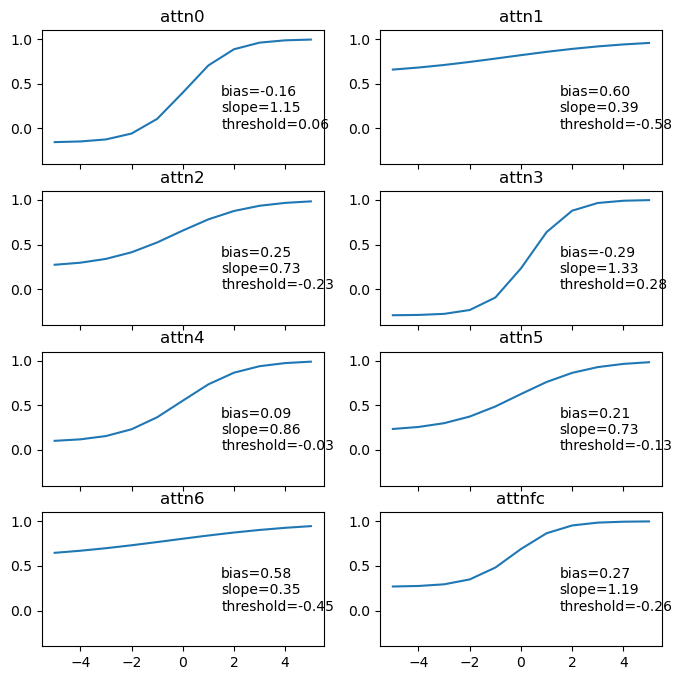

In [16]:
fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True, figsize=(8,8))
axs = axs.ravel()
layer_names = list(attn_params.keys())
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-5,6)

for i, layer in enumerate(attn_params.keys()):
    bias = attn_params[layer]['bias']
    slope = attn_params[layer]['slope']
    threshold = attn_params[layer]['threshold']

    axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
    axs[i].text(1.5, 0., f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    axs[i].set_title(layer_names[i])
    # axs[i].set_ylim(-0.1,1.1)
    axs[i].set_ylim(-0.4,1.1)

    
    
# plt.tight_layout()

# Look at best performing model

In [10]:
### Get most recent config
config_path = "config/binaural_attn/word_task_half_co_loc_v08_gender_bal_4M_sanity.yaml"
ckpt_path = "attn_cue_models/word_task_half_co_loc_v08_gender_bal_4M_sanity/checkpoints/epoch=7-step=89878.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)


In [18]:
# model = attn_tracking_lightning.BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=True)
model = model.eval()
attn_params = {}
for param in model.named_parameters():
    if 'attn' in param[0]:
        layer, parameter = param[0].split('.')[3:]
        if layer not in attn_params:
            attn_params[layer] = {}
        attn_params[layer][parameter] = param[1].item()


Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
coch_affine: True
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


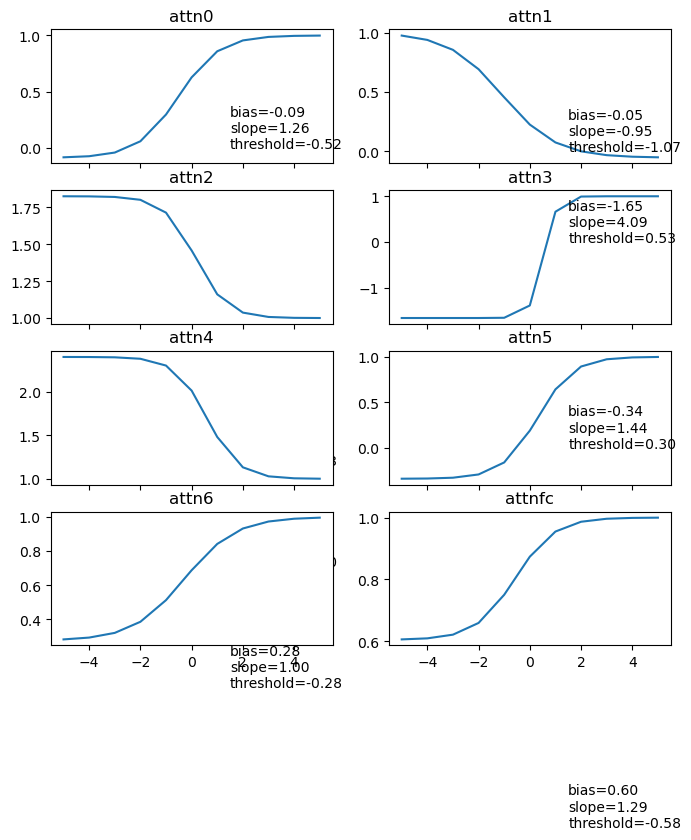

In [19]:
fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True, figsize=(8,8))
axs = axs.ravel()
layer_names = list(attn_params.keys())
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-5,6)

for i, layer in enumerate(attn_params.keys()):
    bias = attn_params[layer]['bias']
    slope = attn_params[layer]['slope']
    threshold = attn_params[layer]['threshold']

    axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
    axs[i].text(1.5, 0., f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    axs[i].set_title(layer_names[i])
    # axs[i].set_ylim(-0.1,1.1)
    # axs[i].set_ylim(-0.4,1.1)

    
    
# plt.tight_layout()

## Conventional layer order model

In [11]:
### Get most recent config
config_path = "config/binaural_attn/word_task_conventional_layer_order.yaml"
ckpt_path = "attn_cue_models/word_task_conventional_layer_order_lr0001/checkpoints/epoch=0-step=8000-v6.ckpt"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)
ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))


In [12]:
# for each ke in ckpt['state_dict'] remove ._orig_module from the key
new_state_dict = {}
for k, v in ckpt['state_dict'].items():
    if '_orig_mod.' in k:
        k = k.replace('_orig_mod.', '')
    new_state_dict[k] = v

ckpt['state_dict'] = new_state_dict
model = BinauralAttentionModule(config=config)


model.load_state_dict(ckpt['state_dict'])

Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNNV2
v08 True
num_classes={'num_words': 800}
Model performing word task
Conv block order: Conv -> LN -> ReLU
Norm first: False
fc_attn: True
coch_affine: True
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


<All keys matched successfully>

In [15]:
# model = BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=True)
model = model.eval()
# attn_params = {}
# for param in model.named_parameters():
#     if 'attn' in param[0]:
#         print(param)
#         layer, parameter = param[0].split('.')[3:]
#         if layer not in attn_params:
#             attn_params[layer] = {}
#         attn_params[layer][parameter] = param[1].item()


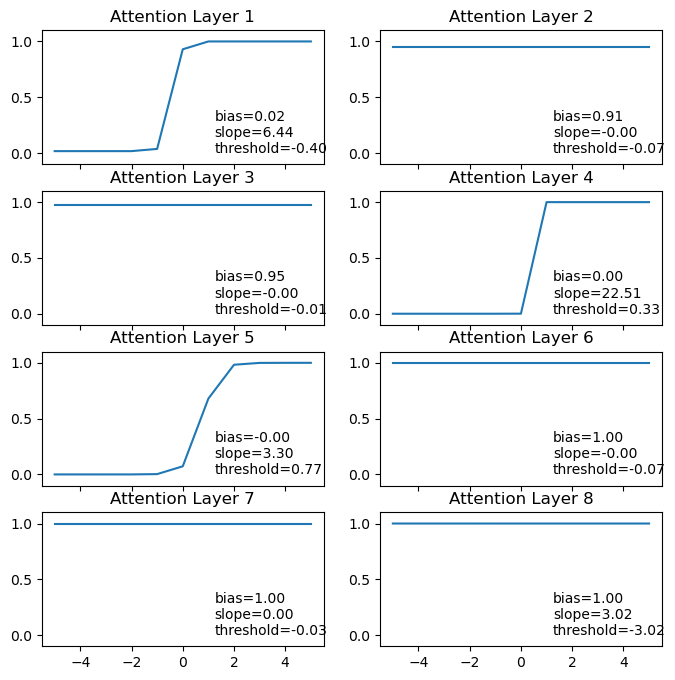

In [17]:
attn_modules = model.attn_modules
n_attn_blocks = len(attn_modules)   

fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True, figsize=(8,8))
axs = axs.ravel()
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-5,6)

for i, module in enumerate(attn_modules):
    bias = module.bias.item()
    slope = module.slope.item()
    threshold = module.threshold.item() 
    layer_name = f"Attention Layer {i+1}"

    axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
    axs[i].text(1.25, 0., f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    axs[i].set_title(layer_name)
    # axs[i].set_ylim(-0.1,1.1)
    axs[i].set_ylim(-0.1,1.1)

    
    
# plt.tight_layout()